# Step 4 — A neural network in PyTorch

**Goal:** let a model learn patterns that Elo and Dixon-Coles can't express on their own, by combining several pieces of information about each match.

**Features (all known *before* kick-off):**
- Elo ratings of both teams and the gap between them (from Step 2)
- Recent form: average points, goals scored and goals conceded over each team's last 10 matches
- Experience: how many matches each team has played in the data
- Venue (neutral or not) and match importance (friendly vs World Cup)

**Output:** P(home win), P(draw), P(away win).

**The golden rule:** every feature must use only information from before the match. Using any information from the match itself is called **data leakage**, and it makes a model look brilliant in testing and useless in real life.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Save everything in Google Drive, so each notebook can use the previous notebook's outputs.
# Colab will ask for permission to access your Drive the first time.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/world-cup-prediction"
except ImportError:          # running on your own computer instead of Colab
    BASE = "."
os.makedirs(BASE, exist_ok=True)
os.chdir(BASE)
for folder in ["data", "models", "preds"]:
    os.makedirs(folder, exist_ok=True)
print("Working folder:", os.getcwd())

Mounted at /content/drive
Working folder: /content/drive/MyDrive/world-cup-prediction


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START_YEAR = 1990

def load_matches():
    """Load cleaned matches (downloading and cleaning them first if needed)."""
    path = "data/matches_clean.csv"
    if not os.path.exists(path):
        raw = pd.read_csv(URL, parse_dates=["date"])
        df = raw.dropna(subset=["home_score", "away_score"])
        df = df[df["date"].dt.year >= START_YEAR].copy()
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["date", "home_team", "away_team"], kind="stable").reset_index(drop=True)
    df["match_id"] = df.index
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["neutral"] = df["neutral"].astype(bool)
    # Result coded as a class: 0 = home win, 1 = draw, 2 = away win
    df["result"] = np.select([df["home_score"] > df["away_score"],
                              df["home_score"] < df["away_score"]], [0, 2], default=1)
    return df

def add_splits(df):
    """train: before 2024 | val: 2024 until the World Cup | test: the 2026 World Cup matches."""
    wc26 = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
    test_start = df.loc[wc26, "date"].min() if wc26.any() else pd.Timestamp("2026-06-11")
    val_start = pd.Timestamp("2024-01-01")
    df["split"] = np.select([df["date"] < val_start, df["date"] < test_start, wc26],
                            ["train", "val", "test"], default="after")
    return df, val_start, test_start

matches, VAL_START, TEST_START = add_splits(load_matches())
print(matches["split"].value_counts().to_string())
print("Validation starts:", VAL_START.date(), "| Test (World Cup 2026) starts:", TEST_START.date())

split
train    29787
val       2564
after      366
test       104
Validation starts: 2024-01-01 | Test (World Cup 2026) starts: 2026-06-11


## Train / validation / test split

To judge the models honestly, they must be tested on matches they have **never seen**:

| Split | Matches | Used for |
| --- | --- | --- |
| **train** | before 2024 | fitting the models |
| **val** | 2024 → start of World Cup 2026 | comparing models and tuning settings |
| **test** | the 2026 World Cup itself | the final, one-time exam |

Splitting by **time** (not randomly) matters in sport: a model must never learn from the future.

In [3]:
if not os.path.exists("data/elo_features.csv"):
    raise FileNotFoundError("Run notebook 02 (Elo) first — it creates data/elo_features.csv")
elo = pd.read_csv("data/elo_features.csv")
data = matches.merge(elo, on="match_id")
print(f"{len(data):,} matches with Elo features")

32,821 matches with Elo features


## 2. Recent-form features

We rearrange the data so each row is one team in one match, then compute rolling averages over the **previous** 10 matches. The `.shift(1)` is what prevents leakage: it moves the window back by one match, so a match's own result is never included.

In [4]:
WINDOW = 10

def team_long(df):
    """One row per team per match."""
    home = pd.DataFrame({"match_id": df["match_id"], "date": df["date"], "team": df["home_team"],
                         "gf": df["home_score"], "ga": df["away_score"]})
    away = pd.DataFrame({"match_id": df["match_id"], "date": df["date"], "team": df["away_team"],
                         "gf": df["away_score"], "ga": df["home_score"]})
    long = pd.concat([home, away]).sort_values(["date", "match_id"], kind="stable").reset_index(drop=True)
    long["pts"] = np.select([long["gf"] > long["ga"], long["gf"] == long["ga"]], [3, 1], default=0)
    return long

long = team_long(matches)
grouped = long.groupby("team")
for col in ["pts", "gf", "ga"]:
    long[f"form_{col}"] = grouped[col].transform(lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean())
    long[f"form_{col}"] = long[f"form_{col}"].fillna(long[col].mean())   # a team's very first match
long["games_played"] = np.log1p(grouped.cumcount())                      # matches played before this one
long.head()

,match_id,date,team,gf,ga,pts,form_pts,form_gf,form_ga,games_played
0,0,1990-01-12,Algeria,5,0,3,1.382743,1.381296,1.381296,0.000000
1,0,1990-01-12,Mali,0,5,0,1.382743,1.381296,1.381296,0.000000
2,1,1990-01-14,Algeria,3,1,3,3.000000,5.000000,0.000000,0.693147
3,1,1990-01-14,Cameroon,1,3,0,1.382743,1.381296,1.381296,0.000000
4,2,1990-01-17,Greece,2,0,3,1.382743,1.381296,1.381296,0.000000


In [5]:
FORM_COLS = ["form_pts", "form_gf", "form_ga", "games_played"]
for side in ["home", "away"]:
    side_feats = long[["match_id", "team"] + FORM_COLS].rename(
        columns={"team": f"{side}_team", **{c: f"{side}_{c}" for c in FORM_COLS}})
    data = data.merge(side_feats, on=["match_id", f"{side}_team"])

def k_factor(tournament):
    """Same importance rule as Step 2."""
    if tournament == "FIFA World Cup": return 60
    if "qualification" in tournament.lower(): return 40
    if tournament in {"UEFA Euro", "Copa América", "African Cup of Nations", "AFC Asian Cup", "Gold Cup",
                      "CONCACAF Championship", "Confederations Cup", "UEFA Nations League",
                      "CONCACAF Nations League", "OFC Nations Cup"}: return 50
    if tournament == "Friendly": return 20
    return 30

data["importance"] = data["tournament"].map(k_factor) / 60
data["is_neutral"] = data["neutral"].astype(float)

FEATURES = ["elo_diff", "home_elo", "away_elo", "is_neutral", "importance",
            "home_form_pts", "home_form_gf", "home_form_ga", "home_games_played",
            "away_form_pts", "away_form_gf", "away_form_ga", "away_games_played"]
data[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
elo_diff,32821.0,69.71,228.44,-1150.91,-64.06,69.13,204.82,1295.12
home_elo,32821.0,1578.91,215.12,816.43,1449.06,1574.50,1720.28,2331.15
away_elo,32821.0,1562.89,212.94,817.96,1439.28,1561.86,1700.44,2332.50
is_neutral,32821.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00
importance,32821.0,0.55,0.18,0.33,0.33,0.67,0.67,1.00
home_form_pts,32821.0,1.40,0.59,0.00,1.00,1.40,1.80,3.00
home_form_gf,32821.0,1.40,0.68,0.00,0.90,1.30,1.80,12.00
home_form_ga,32821.0,1.36,0.82,0.00,0.90,1.20,1.60,19.00
home_games_played,32821.0,4.76,1.12,0.00,4.25,5.05,5.59,6.50
away_form_pts,32821.0,1.36,0.59,0.00,1.00,1.40,1.80,3.00


## 3. Prepare training data

Neural networks train best when every feature is on a similar scale, so we **standardise** them (mean 0, standard deviation 1). The scaler is fitted on the training set only; fitting it on all the data would be another small form of leakage.

In [6]:
from sklearn.preprocessing import StandardScaler

train = data[(data["split"] == "train") & (data["date"].dt.year >= 1994)]   # skip Elo burn-in years
val = data[data["split"] == "val"]
test = data[data["split"] == "test"]

scaler = StandardScaler().fit(train[FEATURES])
X_train, X_val, X_test = (scaler.transform(d[FEATURES]) for d in (train, val, test))
y_train, y_val = train["result"].values, val["result"].values
print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")

train 27,401 | val 2,564 | test 104


## 4. Build and train the network

A small network is enough here: 13 inputs → 32 neurons → 16 neurons → 3 outputs.
- **ReLU** activations let it learn non-linear patterns.
- **Dropout** randomly switches off neurons during training, which reduces overfitting.
- **Early stopping:** we watch the validation loss after every epoch and keep the best version. When the model stops improving on unseen data, it's starting to memorise the training data.

In [7]:
import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

def build_model(n_features):
    return nn.Sequential(
        nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 3))

model = build_model(len(FEATURES))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.long)
Xv = torch.tensor(X_val, dtype=torch.float32)
yv = torch.tensor(y_val, dtype=torch.long)
model

Sequential(
  (0): Linear(in_features=13, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=3, bias=True)
)

Early stopping at epoch 46
Best validation log loss: 0.8623


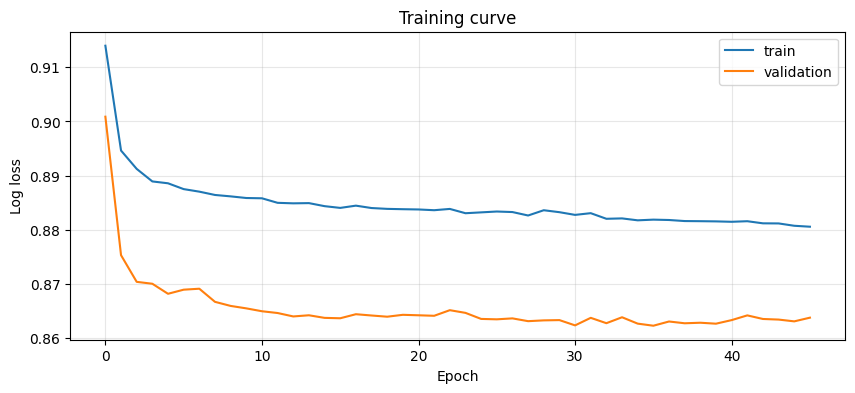

In [8]:
EPOCHS, BATCH, PATIENCE = 200, 256, 15
history = {"train": [], "val": []}
best_loss, best_state, waited = float("inf"), None, 0

for epoch in range(EPOCHS):
    model.train()
    order = torch.randperm(len(Xt))
    for start in range(0, len(Xt), BATCH):
        batch = order[start:start + BATCH]
        optimizer.zero_grad()
        loss = loss_fn(model(Xt[batch]), yt[batch])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = loss_fn(model(Xt), yt).item()
        val_loss = loss_fn(model(Xv), yv).item()
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_loss - 1e-4:
        best_loss, waited = val_loss, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        waited += 1
        if waited >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

model.load_state_dict(best_state)
print(f"Best validation log loss: {best_loss:.4f}")

plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.xlabel("Epoch"); plt.ylabel("Log loss"); plt.title("Training curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Reading the training curve:** both lines should fall at first. If the validation line starts rising while the training line keeps falling, the model is **overfitting**, and early stopping saves the version from just before that point.

In [9]:
def predict_nn(X):
    model.eval()
    with torch.no_grad():
        return torch.softmax(model(torch.tensor(X, dtype=torch.float32)), dim=1).numpy()

p_val, p_test = predict_nn(X_val), predict_nn(X_test)

## 5. How good is it?

In [10]:
from sklearn.metrics import log_loss, accuracy_score

print(f"Validation log loss: {log_loss(y_val, p_val, labels=[0, 1, 2]):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, p_val.argmax(axis=1)):.1%}")
print("Share of matches predicted as each outcome (home / draw / away):",
      np.bincount(p_val.argmax(axis=1), minlength=3) / len(p_val))
print("Actual share:", np.bincount(y_val, minlength=3) / len(y_val))

Validation log loss: 0.8623
Validation accuracy: 60.3%
Share of matches predicted as each outcome (home / draw / away): [0.64937598 0.00390016 0.34672387]
Actual share: [0.47386895 0.23634945 0.28978159]


**Notice the draws:** the model almost never picks a draw as the *most likely* outcome, even though roughly a quarter of matches end level. That's normal. A draw is rarely the single most likely result, but its probability still matters, which is why we judge models on **log loss** rather than accuracy alone.

## 6. Save predictions, the model and a pre-World Cup team snapshot

In [12]:
out = pd.concat([
    pd.DataFrame({"match_id": val["match_id"].values, "p_home": p_val[:, 0], "p_draw": p_val[:, 1], "p_away": p_val[:, 2]}),
    pd.DataFrame({"match_id": test["match_id"].values, "p_home": p_test[:, 0], "p_draw": p_test[:, 1], "p_away": p_test[:, 2]})])
out.to_csv("preds/nn_preds.csv", index=False)

# Each team's form and Elo on the eve of the World Cup (used by the simulation in Step 6)
before = long[long["date"] < TEST_START]
snapshot = before.groupby("team").agg(
    form_pts=("pts", lambda s: s.tail(WINDOW).mean()),
    form_gf=("gf", lambda s: s.tail(WINDOW).mean()),
    form_ga=("ga", lambda s: s.tail(WINDOW).mean()),
    games_played=("pts", lambda s: np.log1p(len(s)))).reset_index()
snapshot = snapshot.merge(pd.read_csv("models/elo_ratings_wc2026.csv"), on="team", how="left")
snapshot.to_csv("models/team_snapshot_wc2026.csv", index=False)

import joblib
joblib.dump(scaler, "models/nn_scaler.joblib")
json.dump(FEATURES, open("models/nn_features.json", "w"))
torch.save(model.state_dict(), "models/nn_model.pt")
print("Saved predictions, model, scaler and team snapshot.")

Saved predictions, model, scaler and team snapshot.
